# Part 2A-vi: Custom Activation, Initializer, Regularizer & Kernel Constraint

**Objective:** Implement custom versions of each in both TF and PyTorch.

---

In [1]:
import numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.nn.functional as F

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32")/255.0, X_test.astype("float32")/255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
X_flat_tr, X_flat_te = X_train.reshape(len(X_train),-1), X_test.reshape(len(X_test),-1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


## 1. Custom Activation Function: Parametric Leaky ReLU

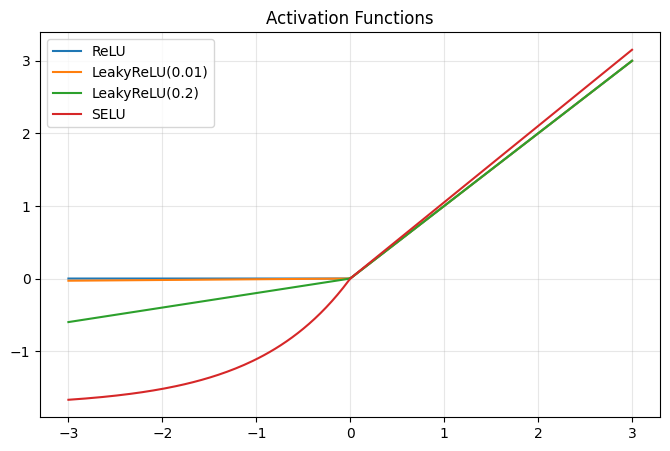

In [2]:
# TF: Custom leaky ReLU as a function and as a layer
def my_leaky_relu(x, alpha=0.2):
    """Leaky ReLU: f(x) = x if x > 0, else alpha * x"""
    return tf.maximum(alpha * x, x)

# Parametric version where alpha is learned
class ParametricReLU(layers.Layer):
    """Parametric ReLU — alpha is a trainable parameter."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.alpha = self.add_weight(
            shape=(input_shape[-1],),
            initializer='zeros', trainable=True, name='alpha'
        )

    def call(self, inputs):
        return tf.maximum(self.alpha * inputs, inputs)

# Visualize
x = np.linspace(-3, 3, 200)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, np.maximum(x, 0), label='ReLU')
ax.plot(x, np.maximum(0.01*x, x), label='LeakyReLU(0.01)')
ax.plot(x, np.maximum(0.2*x, x), label='LeakyReLU(0.2)')
ax.plot(x, np.where(x > 0, x, 1.67326*(np.exp(x)-1)) * 1.0507, label='SELU')
ax.set_title('Activation Functions'); ax.legend(); ax.grid(True, alpha=0.3); plt.show()

## 2. Custom Initializer: My Glorot

In [3]:
# TF: Custom Glorot initializer
class MyGlorotInitializer(keras.initializers.Initializer):
    """Custom Glorot/Xavier initialization.
    Samples from U(-limit, limit) where limit = sqrt(6 / (fan_in + fan_out))
    """
    def __call__(self, shape, dtype=None, **kwargs):
        fan_in = shape[0]
        fan_out = shape[1] if len(shape) > 1 else shape[0]
        limit = tf.sqrt(6.0 / tf.cast(fan_in + fan_out, tf.float32))
        return tf.random.uniform(shape, -limit, limit, dtype=dtype or tf.float32)

    def get_config(self):
        return {}

# Test it
test_weights = MyGlorotInitializer()((256, 128))
print(f"Custom Glorot weights — mean: {test_weights.numpy().mean():.4f}, std: {test_weights.numpy().std():.4f}")

Custom Glorot weights — mean: 0.0000, std: 0.0724


## 3. Custom Regularizer: L1 with Threshold

In [4]:
# TF: Custom L1 regularizer
class MyL1Regularizer(keras.regularizers.Regularizer):
    """L1 regularizer that only penalizes weights above a threshold.
    This encourages sparsity while allowing small weights to exist freely.
    """
    def __init__(self, factor=0.01, threshold=0.01):
        self.factor = factor
        self.threshold = threshold

    def __call__(self, weights):
        mask = tf.cast(tf.abs(weights) > self.threshold, tf.float32)
        return self.factor * tf.reduce_sum(tf.abs(weights) * mask)

    def get_config(self):
        return {"factor": float(self.factor), "threshold": float(self.threshold)}

## 4. Custom Kernel Constraint: Positive Weights

In [5]:
# TF: Custom constraint — force weights to be non-negative
class MyPositiveWeights(keras.constraints.Constraint):
    """Clips weights to be >= 0 after each gradient update.
    Useful in certain architectures where negative weights don't make sense.
    """
    def __call__(self, weights):
        return tf.nn.relu(weights)

# Put it all together — use all custom components
model = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(256, activation=my_leaky_relu,
                 kernel_initializer=MyGlorotInitializer(),
                 kernel_regularizer=MyL1Regularizer(0.001)),
    ParametricReLU(),
    layers.Dense(128, kernel_initializer=MyGlorotInitializer(),
                 kernel_regularizer=MyL1Regularizer(0.001),
                 kernel_constraint=MyPositiveWeights()),
    layers.ReLU(),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h = model.fit(X_flat_tr, y_train, epochs=20, batch_size=256, validation_split=0.2, verbose=1)
print(f"Best val_acc: {max(h.history['val_accuracy']):.4f}")

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.2594 - loss: 6.0600 - val_accuracy: 0.3199 - val_loss: 2.4060
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3317 - loss: 2.2593 - val_accuracy: 0.3483 - val_loss: 2.1641
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3448 - loss: 2.1440 - val_accuracy: 0.3369 - val_loss: 2.1424
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3503 - loss: 2.0931 - val_accuracy: 0.3533 - val_loss: 2.0581
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3608 - loss: 2.0310 - val_accuracy: 0.3648 - val_loss: 2.0359
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3622 - loss: 2.0229 - val_accuracy: 0.3319 - val_loss: 2.0701
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3693 - loss: 2.0023 - val_accuracy: 0.3309 - val_loss: 2.0980
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3726 - loss: 1.9898 - val_accuracy: 0

In [ ]:
# PyTorch: All custom components
class LeakyReLUCustom(nn.Module):
    def __init__(self, alpha=0.2): super().__init__(); self.alpha = alpha
    def forward(self, x): return torch.where(x > 0, x, self.alpha * x)

def glorot_init(m):
    if isinstance(m, nn.Linear):
        fan_in, fan_out = m.weight.shape[1], m.weight.shape[0]
        limit = (6.0 / (fan_in + fan_out)) ** 0.5
        nn.init.uniform_(m.weight, -limit, limit)

class PositiveWeightConstraint:
    """Apply after optimizer step to clip weights >= 0."""
    @staticmethod
    def apply(model):
        for m in model.modules():
            if isinstance(m, nn.Linear):
                m.weight.data.clamp_(min=0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pt_model = nn.Sequential(
    nn.Linear(3072, 256), LeakyReLUCustom(0.2),
    nn.Linear(256, 128), nn.ReLU(),
    nn.Linear(128, 10)
).to(device)
pt_model.apply(glorot_init)

opt = torch.optim.Adam(pt_model.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(torch.FloatTensor(X_flat_tr), torch.LongTensor(y_train)),
    batch_size=256, shuffle=True)
for ep in range(20):
    pt_model.train()
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(pt_model(xb), yb)
        l1 = sum(p.abs().sum() for p in pt_model.parameters()) * 1e-5
        (loss + l1).backward(); opt.step()
pt_model.eval()
with torch.no_grad():
    acc = (pt_model(torch.FloatTensor(X_flat_te).to(device)).argmax(1)==torch.LongTensor(y_test).to(device)).float().mean()
print(f"PyTorch Custom Components Test Acc: {acc:.4f}")

## Key Takeaways
- Custom activation: subclass `Layer` in TF or `nn.Module` in PyTorch
- Custom initializer: subclass `keras.initializers.Initializer` in TF
- Custom regularizer: subclass `keras.regularizers.Regularizer` in TF; add penalty to loss in PyTorch
- Custom constraint: subclass `keras.constraints.Constraint` in TF; clip after opt.step() in PyTorch
- All components are composable — mix and match for your architecture